In [1]:
# Vector data
import geopandas as gpd
from shapely.geometry import Point, Polygon

# Visualization
import matplotlib.pyplot as plt
import folium


In [2]:
# 1. Load and Explore LGA Data

# Load Lagos LGAs shapefile
lga_b = gpd.read_file('/content/delta_lga.geojson')
print(lga_b.head())
print("CRS:", lga_b.crs)


   fid       GID_2 GID_0  COUNTRY     GID_1 NAME_1 NL_NAME_1         NAME_2  \
0  188  NGA.10.1_1   NGA  Nigeria  NGA.10_1  Delta        NA  Aniocha North   
1  189  NGA.10.2_1   NGA  Nigeria  NGA.10_1  Delta        NA  Aniocha South   
2  190  NGA.10.3_1   NGA  Nigeria  NGA.10_1  Delta        NA         Bomadi   
3  191  NGA.10.4_1   NGA  Nigeria  NGA.10_1  Delta        NA         Burutu   
4  192  NGA.10.6_1   NGA  Nigeria  NGA.10_1  Delta        NA   Ethiope East   

  VARNAME_2 NL_NAME_2           TYPE_2        ENGTYPE_2 CC_2 HASC_2  \
0        NA        NA  Local Authority  Local Authority   NA     NA   
1        NA        NA  Local Authority  Local Authority   NA     NA   
2        NA        NA  Local Authority  Local Authority   NA     NA   
3        NA        NA  Local Authority  Local Authority   NA     NA   
4        NA        NA  Local Authority  Local Authority   NA     NA   

                                            geometry  
0  MULTIPOLYGON (((6.61403 6.24945, 6.61373

In [3]:
# 2. Load Health Facility Points

lga_hf = gpd.read_file('/content/delta_hf.geojson')
print(lga_hf.head())
print("CRS:", lga_hf.crs)


   OBJECTID                              globalid    nhfr_uid  \
0      1190  5ac25ac3-ec82-48a5-903c-599b57b57d52  14474545.0   
1      1262  80134014-76e8-445e-9302-fdf4a04e85c4  76285497.0   
2      1263  26cd3340-c7b4-4dc5-a27d-673a64bf5696  84819975.0   
3      1264  af9bb45d-6b9c-4cbb-901e-f8f98d8dfc7b  59798624.0   
4      1895  953a7271-e822-4b04-9f67-3945a4e8140a  35215898.0   

  nhfr_facility_code  country  iso  state            lga  \
0   10/17/1/1/2/0003  Nigeria  NGA  Delta         Sapele   
1   10/20/1/2/1/0001  Nigeria  NGA  Delta  Ughelli South   
2   10/11/1/1/1/0025  Nigeria  NGA  Delta    Ndokwa East   
3   10/12/1/1/2/0003  Nigeria  NGA  Delta    Ndokwa West   
4   10/24/1/1/2/0019  Nigeria  NGA  Delta    Warri South   

   lga_name_disagreement          ward  ...  facility_name_source ownership  \
0                      0          Okpe  ...             NHFR_2024   Private   
1                      0       Olumo 3  ...             NHFR_2024    Public   
2          

In [4]:
lga_hf.columns

Index(['OBJECTID', 'globalid', 'nhfr_uid', 'nhfr_facility_code', 'country',
       'iso', 'state', 'lga', 'lga_name_disagreement', 'ward',
       'ward_name_disagreement', 'facility_name', 'facility_name_source',
       'ownership', 'ownership_type', 'facility_level',
       'facility_level_option', 'latitude', 'longitude',
       'geocoordinates_source', 'last_updated', 'geometry'],
      dtype='object')

In [5]:
# Spatial Join: Determine LGA for Each Hospital


hf_lga = gpd.sjoin(lga_hf, lga_b, how='left', predicate='within')
hf_lga.head()

,OBJECTID,globalid,nhfr_uid,nhfr_facility_code,country,iso,state,lga,lga_name_disagreement,ward,...,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2
0,1190,5ac25ac3-ec82-48a5-903c-599b57b57d52,14474545.0,10/17/1/1/2/0003,Nigeria,NGA,Delta,Sapele,0,Okpe,...,NGA.10_1,Delta,NA,Sapele,NA,NA,Local Authority,Local Authority,NA,NA
1,1262,80134014-76e8-445e-9302-fdf4a04e85c4,76285497.0,10/20/1/2/1/0001,Nigeria,NGA,Delta,Ughelli South,0,Olumo 3,...,NGA.10_1,Delta,NA,Ughelli South,NA,NA,Local Authority,Local Authority,NA,NA
2,1263,26cd3340-c7b4-4dc5-a27d-673a64bf5696,84819975.0,10/11/1/1/1/0025,Nigeria,NGA,Delta,Ndokwa East,0,Onyah/Umuolu,...,NGA.10_1,Delta,NA,Ndokwa East,NA,NA,Local Authority,Local Authority,NA,NA
3,1264,af9bb45d-6b9c-4cbb-901e-f8f98d8dfc7b,59798624.0,10/12/1/1/2/0003,Nigeria,NGA,Delta,Ndokwa West,0,Emu,...,NGA.10_1,Delta,NA,Ndokwa West,NA,NA,Local Authority,Local Authority,NA,NA
4,1895,953a7271-e822-4b04-9f67-3945a4e8140a,35215898.0,10/24/1/1/2/0019,Nigeria,NGA,Delta,Warri South,0,Avenue,...,NGA.10_1,Delta,NA,Warri South,NA,NA,Local Authority,Local Authority,NA,NA


In [6]:
hf_lga.columns

Index(['OBJECTID', 'globalid', 'nhfr_uid', 'nhfr_facility_code', 'country',
       'iso', 'state', 'lga', 'lga_name_disagreement', 'ward',
       'ward_name_disagreement', 'facility_name', 'facility_name_source',
       'ownership', 'ownership_type', 'facility_level',
       'facility_level_option', 'latitude', 'longitude',
       'geocoordinates_source', 'last_updated', 'geometry', 'index_right',
       'fid', 'GID_2', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1',
       'NAME_2', 'VARNAME_2', 'NL_NAME_2', 'TYPE_2', 'ENGTYPE_2', 'CC_2',
       'HASC_2'],
      dtype='object')

In [7]:
print(hf_lga[['facility_name','lga', 'ward','latitude', 'longitude']])

                                  facility_name            lga          ward  \
0              Divine Care Clinic and Maternity         Sapele          Okpe   
1            Effurun Otor Primary Health Center  Ughelli South       Olumo 3   
2              Onya Comprehensive Health Center    Ndokwa East  Onyah/Umuolu   
3         Emu Ebendo Primary Health Care Center    Ndokwa West           Emu   
4                       First Rank Ltd Hospital    Warri South        Avenue   
...                                         ...            ...           ...   
1054                            Mascap Hospital    Warri South         Ubeji   
1055                    Mid West Maternity Home    Warri South         Bowen   
1056               St Georges Specialist Clinic    Warri South    Okere Ward   
1057          Rapha Children Specialist Clinic.          Uvwie    Ugborikoko   
1058  The Pinnacle International Medical Center          Uvwie         Alaka   

      latitude  longitude  
0     5.897

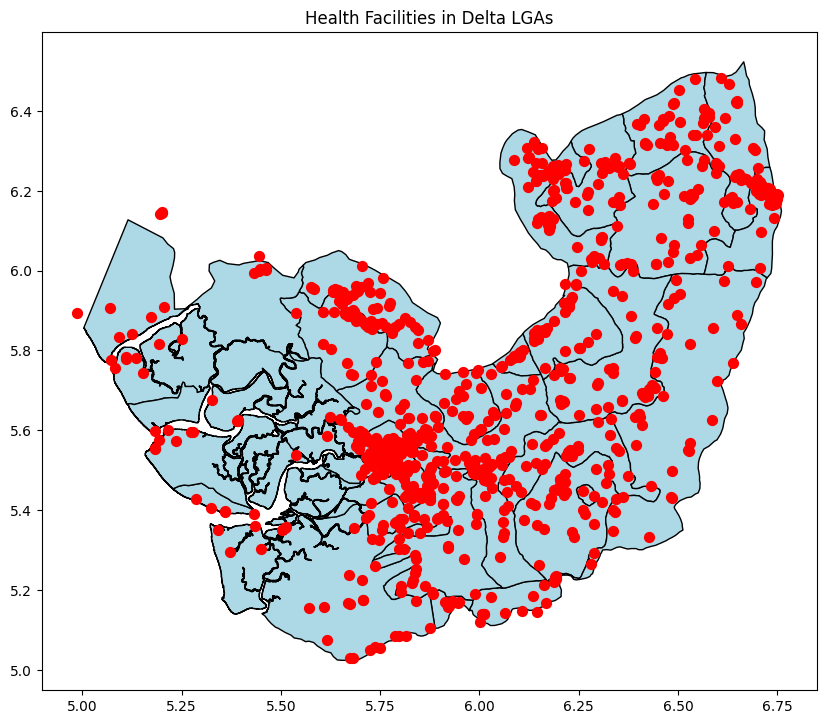

In [9]:
#4.0. Visulaisation

# 4a. Static Map using Matplotlib
fig, ax = plt.subplots(figsize=(10, 10))

lga_b.plot(ax=ax, color='lightblue', edgecolor='black', linewidth= 1)
lga_hf.plot(ax=ax, color='red', markersize= 50)
plt.title("Health Facilities in Delta LGAs")
plt.show()

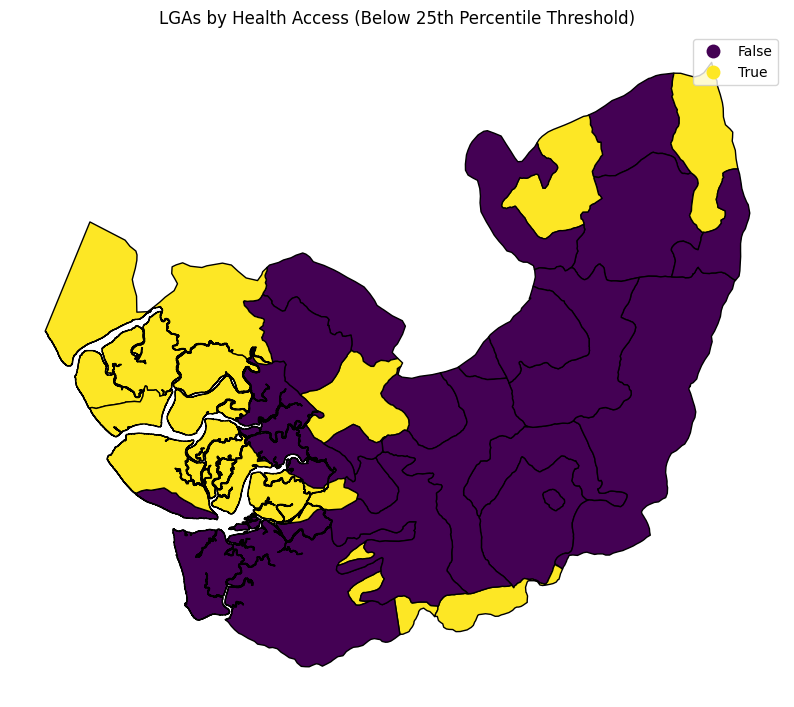

In [10]:
#b) Where there are scarcity of health fcailities

areas = gpd.read_file("delta_lga.geojson").to_crs(epsg=4326)

facility_counts = (
    hf_lga
    .groupby("lga")
    .size()
    .reset_index(name="facility_count")
)

# Merge back to areas
areas = areas.merge(facility_counts, left_on="NAME_2", right_on="lga", how="left")
areas["facility_count"] = areas["facility_count"].fillna(0)


threshold = areas["facility_count"].quantile(0.25)

areas["low_health_access"] = areas["facility_count"] <= threshold


fig, ax = plt.subplots(1, 1, figsize=(10, 10))
areas.plot(
    column='low_health_access',
    cmap='viridis',
    legend=True,
    ax=ax,
    edgecolor='black'
)
ax.set_title('LGAs by Health Access (Below 25th Percentile Threshold)')
ax.set_axis_off()
plt.show()

Creating catchment zones for existing facilities...


/tmp/ipython-input-214/1518967418.py:93: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  lagos_boundary = lga_b.unary_union


Created 1056 catchment zones
Average catchment area: 15.77 km²

Identifying underserved areas...
Number of underserved LGAs: 7

Generating recommendations for new facilities...


/tmp/ipython-input-214/1518967418.py:116: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  underserved_lgas['centroid'] = underserved_lgas.geometry.centroid
/tmp/ipython-input-214/1518967418.py:145: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  min_dist = existing_facilities.distance(point).min()


Generated 7 primary recommendations
Generated 7 alternative locations


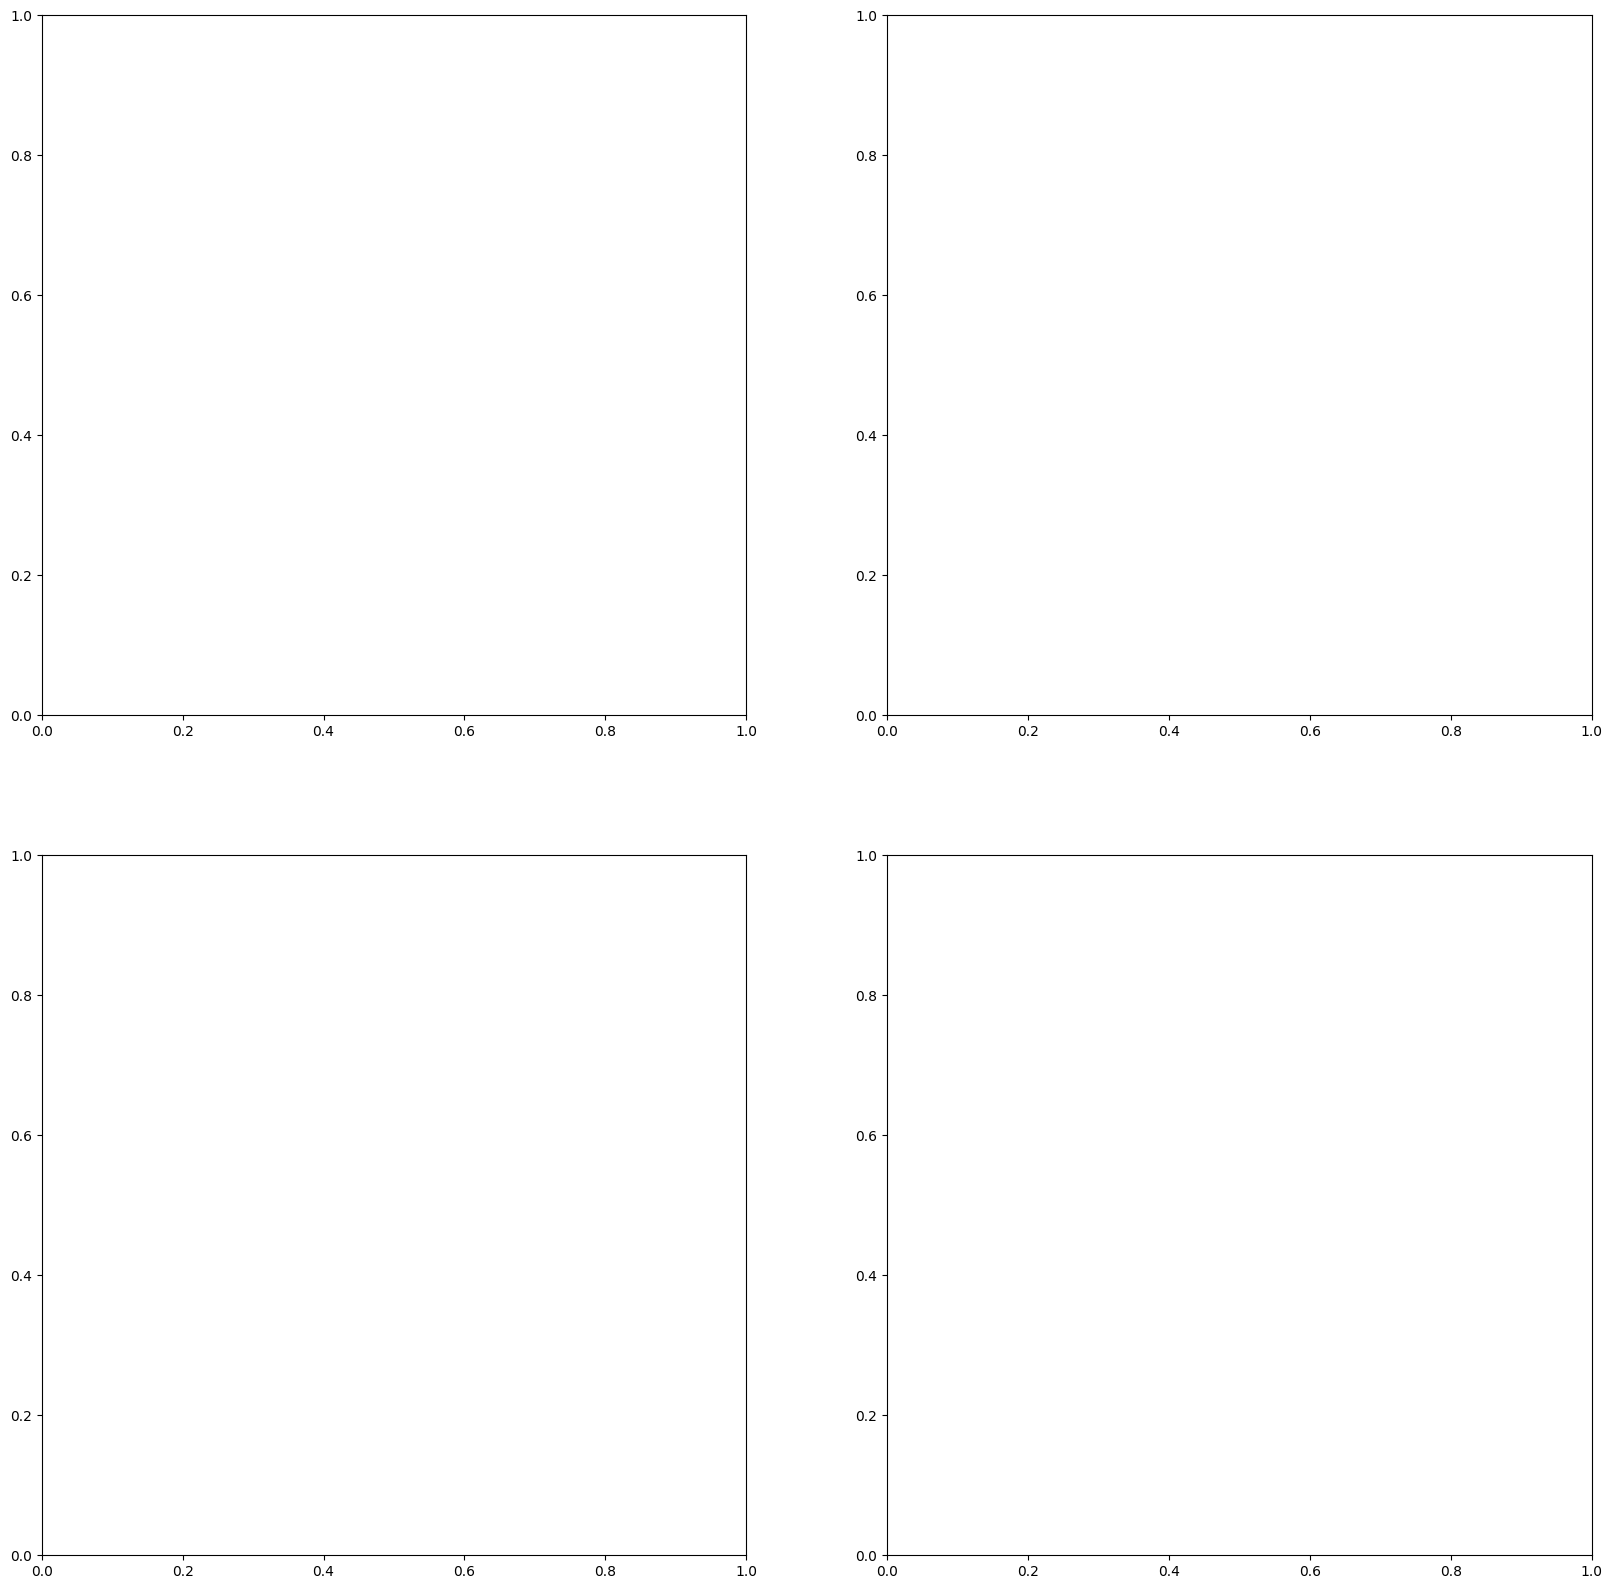

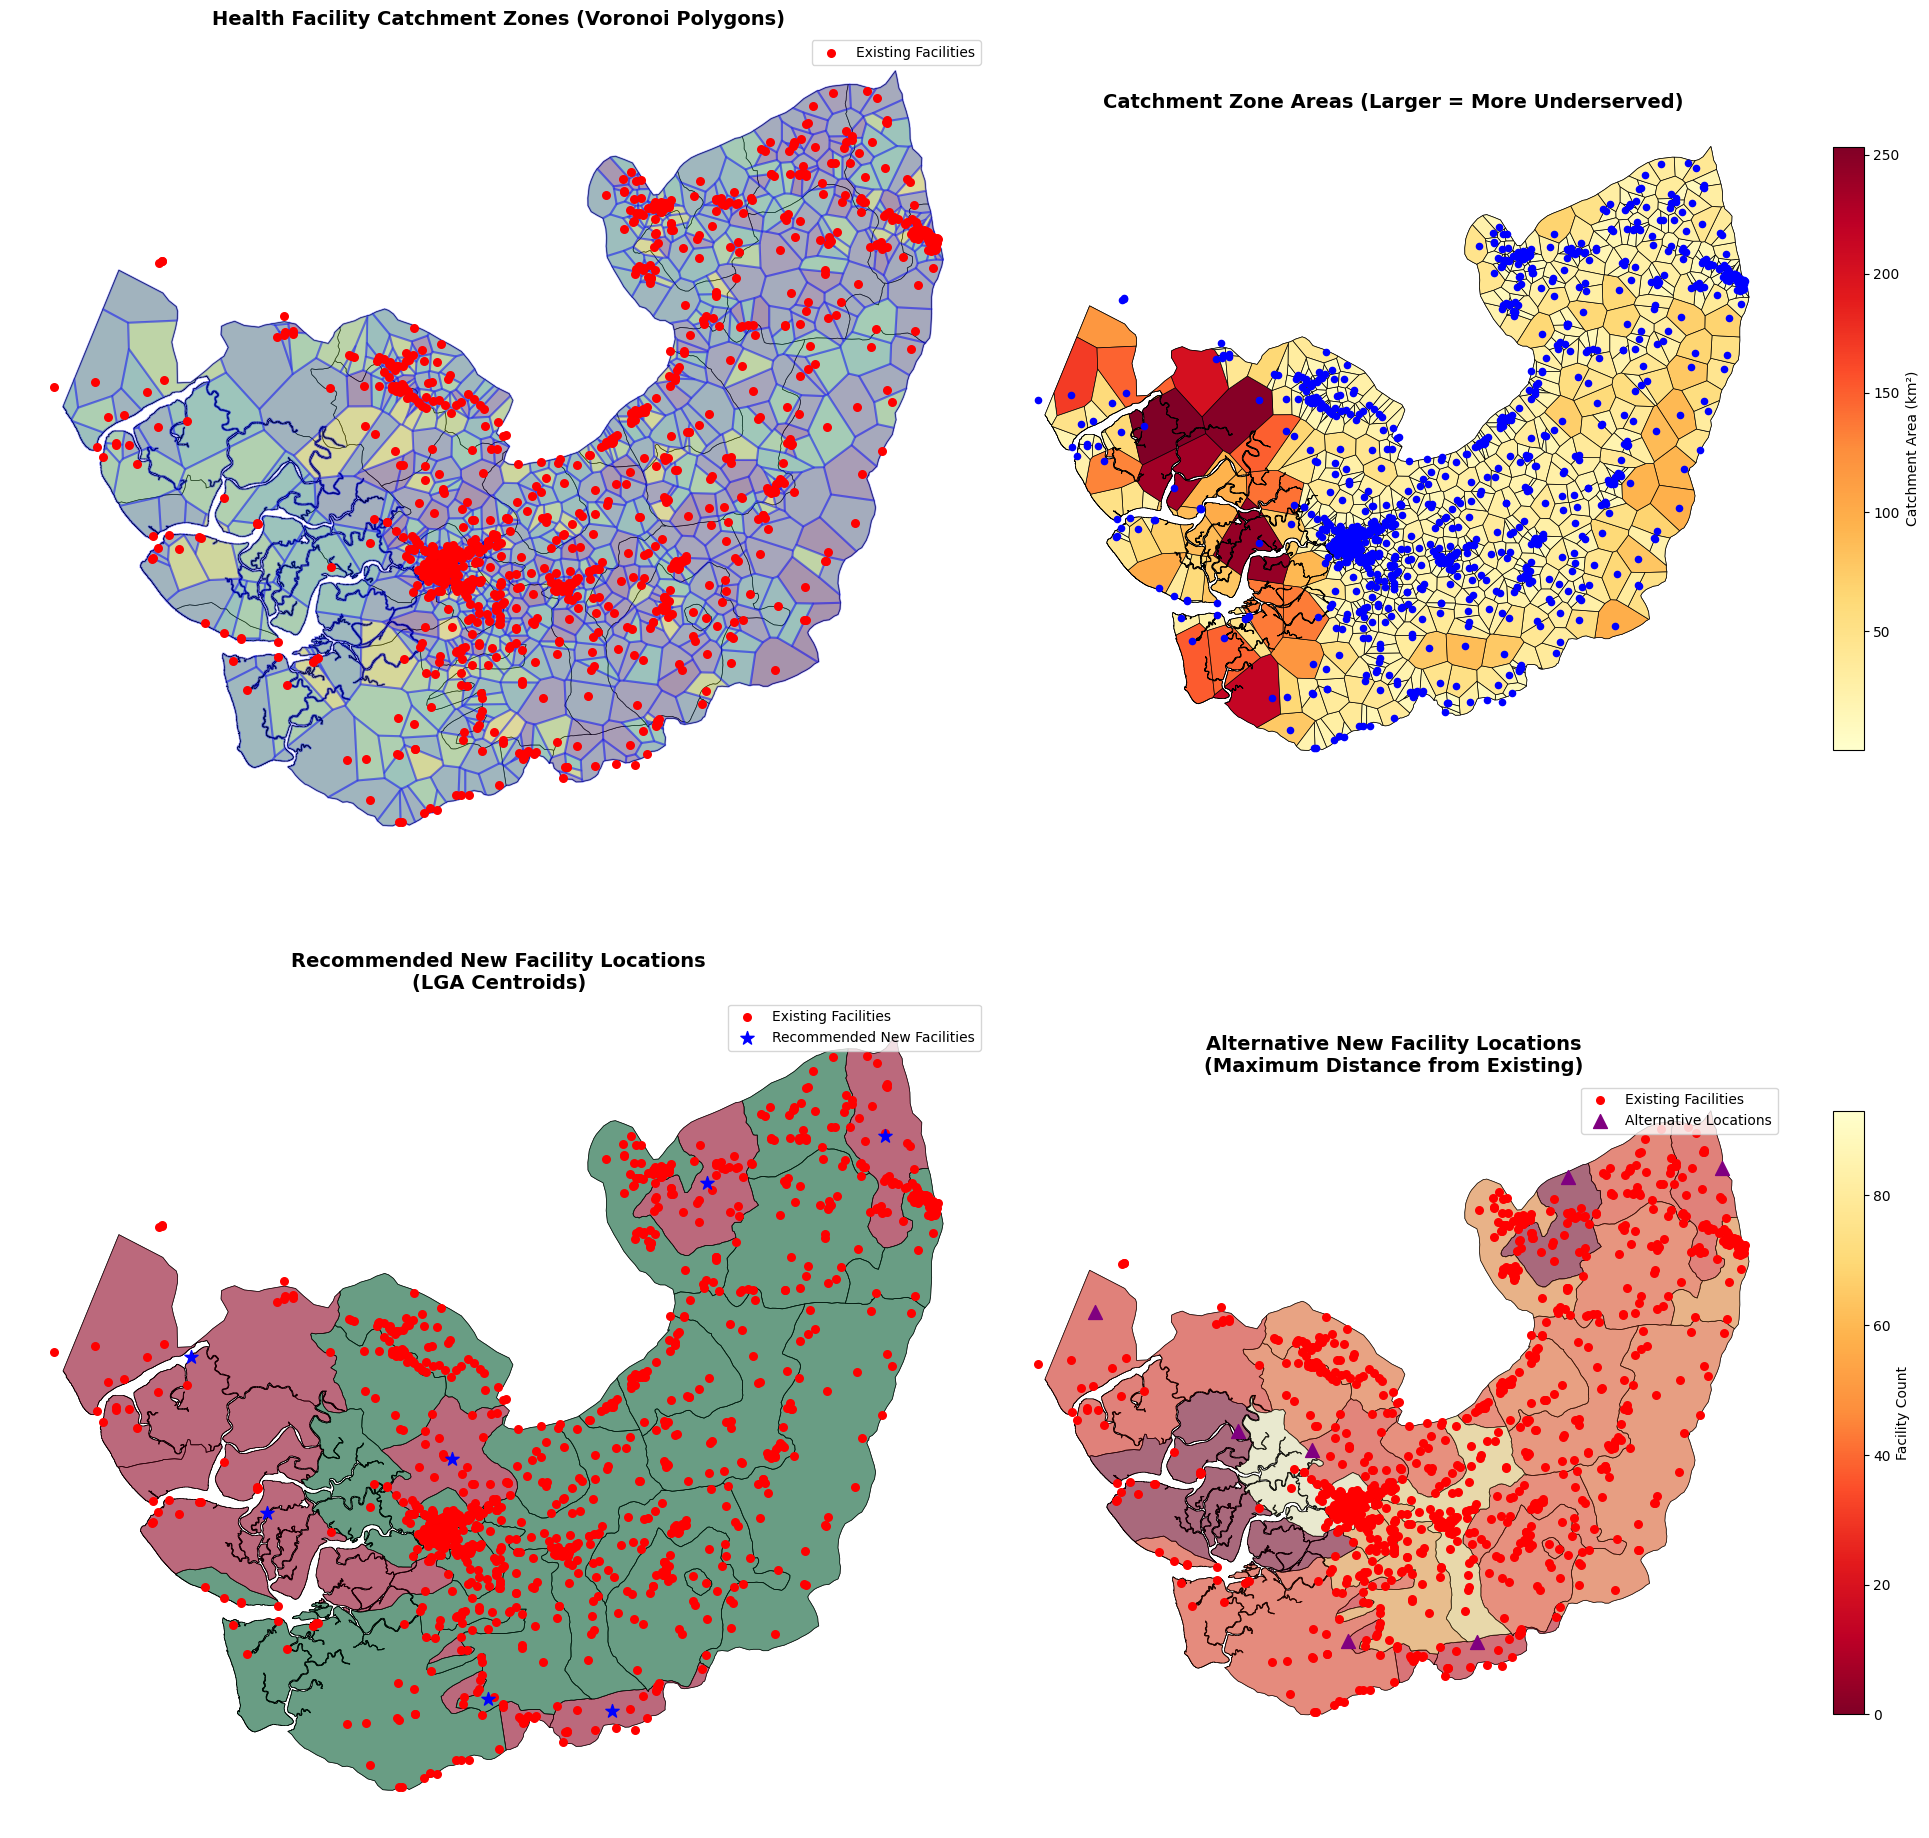


HEALTH FACILITY CATCHMENT ANALYSIS - SUMMARY

Current Situation:
  • Total LGAs: 25
  • Total existing facilities: 1059
  • Underserved LGAs (below 25th percentile): 7
  • Average catchment area: 15.77 km²
  • Largest catchment area: 253.33 km²

Recommendations:
  • Priority new facilities needed: 7

Underserved LGAs requiring new facilities:
    - Bomadi: Currently has 22 facilities
    - Ika North-East: Currently has 0 facilities
    - Okpe: Currently has 30 facilities
    - Oshimili North: Currently has 28 facilities
    - Patani: Currently has 18 facilities
    - Warri North: Currently has 28 facilities
    - Warri South-West: Currently has 0 facilities

Alternative strategic locations (furthest from existing facilities):
    - Bomadi: 0.0425° from nearest facility
    - Ika North-East: 0.0637° from nearest facility
    - Okpe: 0.0474° from nearest facility
    - Oshimili North: 0.0589° from nearest facility
    - Patani: 0.0566° from nearest facility


Files saved:
  • recommende

In [12]:
# c) Catchment Zones and Recommendations for New Facilities

import numpy as np
from scipy.spatial import Voronoi
from shapely.geometry import Point, Polygon
from shapely.ops import unary_union

# 1. CREATE CATCHMENT ZONES (Voronoi/Thiessen Polygons)
print("Creating catchment zones for existing facilities...")

# Get facility coordinates
facility_coords = np.array(list(zip(lga_hf.geometry.x, lga_hf.geometry.y)))

# Create Voronoi diagram
vor = Voronoi(facility_coords)

# Function to create bounded Voronoi polygons
def voronoi_finite_polygons_2d(vor, radius=None):
    """
    Reconstruct infinite Voronoi regions in a 2D diagram to finite regions.
    """
    if vor.points.shape[1] != 2:
        raise ValueError("Requires 2D input")

    new_regions = []
    new_vertices = vor.vertices.tolist()

    center = vor.points.mean(axis=0)
    if radius is None:
        radius = np.ptp(vor.points).max() * 2 # Fixed: Use np.ptp() function

    # Construct a map containing all ridges for a given point
    all_ridges = {}
    for (p1, p2), (v1, v2) in zip(vor.ridge_points, vor.ridge_vertices):
        all_ridges.setdefault(p1, []).append((p2, v1, v2))
        all_ridges.setdefault(p2, []).append((p1, v1, v2))

    # Reconstruct infinite regions
    for p1, region in enumerate(vor.point_region):
        vertices = vor.regions[region]

        if all(v >= 0 for v in vertices):
            # finite region
            new_regions.append(vertices)
            continue

        # reconstruct a non-finite region
        ridges = all_ridges[p1]
        new_region = [v for v in vertices if v >= 0]

        for p2, v1, v2 in ridges:
            if v2 < 0:
                v1, v2 = v2, v1
            if v1 >= 0:
                continue
            # Compute the missing endpoint of an infinite ridge
            t = vor.points[p2] - vor.points[p1]
            t /= np.linalg.norm(t)
            n = np.array([-t[1], t[0]])

            midpoint = vor.points[[p1, p2]].mean(axis=0)
            direction = np.sign(np.dot(midpoint - center, n)) * n
            far_point = vor.vertices[v2] + direction * radius

            new_region.append(len(new_vertices))
            new_vertices.append(far_point.tolist())

        # Sort region counterclockwise
        vs = np.asarray([new_vertices[v] for v in new_region])
        c = vs.mean(axis=0)
        angles = np.arctan2(vs[:, 1] - c[1], vs[:, 0] - c[0])
        new_region = np.array(new_region)[np.argsort(angles)]

        new_regions.append(new_region.tolist())

    return new_regions, np.asarray(new_vertices)

# Generate bounded Voronoi polygons
regions, vertices = voronoi_finite_polygons_2d(vor)

# Create GeoDataFrame for catchment zones
catchment_polygons = []
for region in regions:
    polygon = vertices[region]
    catchment_polygons.append(Polygon(polygon))

catchment_zones = gpd.GeoDataFrame(
    {'geometry': catchment_polygons},
    crs=lga_hf.crs
)

# Clip catchment zones to Lagos boundary
lagos_boundary = lga_b.unary_union
catchment_zones['geometry'] = catchment_zones.geometry.apply(
    lambda x: x.intersection(lagos_boundary)
)
catchment_zones = catchment_zones[~catchment_zones.geometry.is_empty]

# Calculate catchment zone areas (in km²)
catchment_zones_metric = catchment_zones.to_crs(epsg=32631)  # UTM Zone 31N for Lagos
catchment_zones['area_km2'] = catchment_zones_metric.geometry.area / 1_000_000

print(f"Created {len(catchment_zones)} catchment zones")
print(f"Average catchment area: {catchment_zones['area_km2'].mean():.2f} km²")


# 2. IDENTIFY UNDERSERVED AREAS
print("\nIdentifying underserved areas...")


# Find LGAs with low facility counts
underserved_lgas = areas[areas['low_health_access'] == True].copy()
print(f"Number of underserved LGAs: {len(underserved_lgas)}")

# Calculate centroids of underserved areas as potential new facility locations
underserved_lgas['centroid'] = underserved_lgas.geometry.centroid

# 3. RECOMMEND NEW FACILITY LOCATIONS
print("\nGenerating recommendations for new facilities...")

# Strategy 1: Place facilities at centroids of underserved LGAs
recommended_locations = underserved_lgas[['NAME_2', 'centroid', 'facility_count']].copy()
recommended_locations = recommended_locations.rename(columns={'centroid': 'geometry'})
recommended_locations = gpd.GeoDataFrame(recommended_locations, geometry='geometry', crs=areas.crs)

# Strategy 2: Find points furthest from existing facilities
def find_furthest_points(lgas_gdf, existing_facilities, n_points=5):
    """Find points within LGAs that are furthest from existing facilities"""
    furthest_points = []

    for idx, lga in lgas_gdf.iterrows():
        # Create a grid of points within the LGA
        bounds = lga.geometry.bounds
        x = np.linspace(bounds[0], bounds[2], 10)
        y = np.linspace(bounds[1], bounds[3], 10)

        max_distance = 0
        furthest_point = None

        for xi in x:
            for yi in y:
                point = Point(xi, yi)
                if lga.geometry.contains(point):
                    # Calculate minimum distance to any existing facility
                    min_dist = existing_facilities.distance(point).min()
                    if min_dist > max_distance:
                        max_distance = min_dist
                        furthest_point = point

        if furthest_point:
            furthest_points.append({
                'lga': lga['NAME_2'],
                'geometry': furthest_point,
                'distance_to_nearest': max_distance,
                'facility_count': lga['facility_count']
            })

    return gpd.GeoDataFrame(furthest_points, crs=lgas_gdf.crs)

alternative_locations = find_furthest_points(underserved_lgas, lga_hf)

print(f"Generated {len(recommended_locations)} primary recommendations")
print(f"Generated {len(alternative_locations)} alternative locations")


# 4. VISUALIZE RESULTS
fig, axes = plt.subplots(2, 2, figsize=(20, 20))

# 4. VISUALIZE RESULTS
fig, axes = plt.subplots(2, 2, figsize=(20, 20))

# Plot 1: Catchment Zones
ax1 = axes[0, 0]
lga_b.plot(ax=ax1, color='lightgray', edgecolor='black', linewidth=0.5)
catchment_zones.plot(ax=ax1, alpha=0.3, edgecolor='blue', linewidth=1.5, cmap='viridis')
lga_hf.plot(ax=ax1, color='red', markersize=30, label='Existing Facilities')
ax1.set_title('Health Facility Catchment Zones (Voronoi Polygons)', fontsize=14, fontweight='bold')
ax1.set_axis_off()
ax1.legend()

# Plot 2: Catchment Zone Areas
ax2 = axes[0, 1]
lga_b.plot(ax=ax2, color='lightgray', edgecolor='black', linewidth=0.5)
catchment_zones.plot(
    column='area_km2',
    ax=ax2,
    cmap='YlOrRd',
    legend=True,
    edgecolor='black',
    linewidth=0.5,
    legend_kwds={'label': 'Catchment Area (km²)', 'shrink': 0.6}
)
lga_hf.plot(ax=ax2, color='blue', markersize=20)
ax2.set_title('Catchment Zone Areas (Larger = More Underserved)', fontsize=14, fontweight='bold')
ax2.set_axis_off()

# Plot 3: Recommended Locations (Centroid Strategy)
ax3 = axes[1, 0]
lga_b.plot(ax=ax3, color='lightgray', edgecolor='black', linewidth=0.5)
areas.plot(
    column='low_health_access',
    ax=ax3,
    cmap='RdYlGn_r',
    alpha=0.5,
    edgecolor='black',
    linewidth=0.5
)
lga_hf.plot(ax=ax3, color='red', markersize=30, label='Existing Facilities', marker='o')
recommended_locations.plot(ax=ax3, color='blue', markersize=100, label='Recommended New Facilities', marker='*')
ax3.set_title('Recommended New Facility Locations\n(LGA Centroids)', fontsize=14, fontweight='bold')
ax3.set_axis_off()
ax3.legend(loc='upper right')

# Plot 4: Alternative Locations (Maximum Distance Strategy)
ax4 = axes[1, 1]
lga_b.plot(ax=ax4, color='lightgray', edgecolor='black', linewidth=0.5)
areas.plot(
    column='facility_count',
    ax=ax4,
    cmap='YlOrRd_r',
    alpha=0.5,
    edgecolor='black',
    linewidth=0.5,
    legend=True,
    legend_kwds={'label': 'Facility Count', 'shrink': 0.6}
)
lga_hf.plot(ax=ax4, color='red', markersize=30, label='Existing Facilities', marker='o')
alternative_locations.plot(ax=ax4, color='purple', markersize=100, label='Alternative Locations', marker='^')
ax4.set_title('Alternative New Facility Locations\n(Maximum Distance from Existing)', fontsize=14, fontweight='bold')
ax4.set_axis_off()
ax4.legend(loc='upper right')

plt.tight_layout()
plt.savefig('health_facility_recommendations.png', dpi=300, bbox_inches='tight')
plt.show()


# 5. SUMMARY STATISTICS AND RECOMMENDATIONS
print("\n" + "="*60)
print("HEALTH FACILITY CATCHMENT ANALYSIS - SUMMARY")
print("="*60)

print(f"\nCurrent Situation:")
print(f"  • Total LGAs: {len(areas)}")
print(f"  • Total existing facilities: {len(lga_hf)}")
print(f"  • Underserved LGAs (below 25th percentile): {len(underserved_lgas)}")
print(f"  • Average catchment area: {catchment_zones['area_km2'].mean():.2f} km²")
print(f"  • Largest catchment area: {catchment_zones['area_km2'].max():.2f} km²")

print(f"\nRecommendations:")
print(f"  • Priority new facilities needed: {len(recommended_locations)}")
print(f"\nUnderserved LGAs requiring new facilities:")
for idx, row in recommended_locations.iterrows():
    print(f"    - {row['NAME_2']}: Currently has {int(row['facility_count'])} facilities")

print(f"\nAlternative strategic locations (furthest from existing facilities):")
for idx, row in alternative_locations.head(5).iterrows():
    print(f"    - {row['lga']}: {row['distance_to_nearest']:.4f}° from nearest facility")

print("\n" + "="*60)

# Save recommendations to files
recommended_locations.to_file('recommended_new_facilities.geojson', driver='GeoJSON')
alternative_locations.to_file('alternative_facility_locations.geojson', driver='GeoJSON')
catchment_zones.to_file('facility_catchment_zones.geojson', driver='GeoJSON')

print("\nFiles saved:")
print("  • recommended_new_facilities.geojson")
print("  • alternative_facility_locations.geojson")
print("  • facility_catchment_zones.geojson")
print("  • health_facility_recommendations.png")